In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [10]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [11]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.264576,-1.109431,-1.280444,0.993009,3.246703,1
1,-0.432813,-1.258131,-0.403820,-0.080686,2.178338,1
2,-0.940463,0.102418,-0.347854,0.940216,0.004444,1
3,0.534802,2.458303,-1.991727,-0.264093,-1.771629,0
4,-0.306825,1.890987,0.519903,-0.757038,0.515352,1


In [12]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [13]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [14]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [15]:
df1 = combined_sampling(df,0.5,0.5)

In [16]:
df2 = combined_sampling(df,0.5,0.5)

In [17]:
df3 = combined_sampling(df,0.5,0.5)

In [31]:
df3.shape

(50, 3)

In [18]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col2', 'target'], dtype='str')
Index(['col2', 'col4', 'target'], dtype='str')
Index(['col2', 'col1', 'target'], dtype='str')


In [19]:
df3

,col2,col1,target
77,0.248694,3.800847,0
10,0.997413,-0.281866,1
30,3.520066,1.703202,0
45,-1.885518,-1.817514,1
89,0.411655,1.390204,0
55,-0.261795,-2.015359,1
5,0.381522,0.951128,0
5,0.381522,0.951128,0
20,-3.316033,-3.643823,1
25,-1.890468,-0.904316,1


In [20]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [21]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
from sklearn.tree import plot_tree

[Text(0.4, 0.9444444444444444, 'x[1] <= -1.58\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3, 0.8333333333333334, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.35, 0.8888888888888888, 'True  '),
 Text(0.5, 0.8333333333333334, 'x[0] <= 1.232\ngini = 0.438\nsamples = 37\nvalue = [25, 12]'),
 Text(0.45, 0.8888888888888888, '  False'),
 Text(0.3, 0.7222222222222222, 'x[1] <= 1.781\ngini = 0.5\nsamples = 22\nvalue = [11, 11]'),
 Text(0.2, 0.6111111111111112, 'x[0] <= 0.375\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.3, 0.5, 'x[0] <= 0.511\ngini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.2, 0.3888888888888889, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.3888888888888889, 'x[1] <= 0.896\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.3, 0.2777777777777778, 'x[1] <= -0.134\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue =

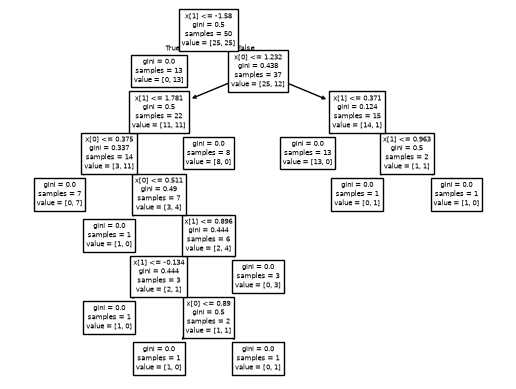

In [23]:
plot_tree(clf1)

[Text(0.625, 0.9375, 'x[0] <= -0.858\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.5, 0.8125, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.5625, 0.875, 'True  '),
 Text(0.75, 0.8125, 'x[0] <= 1.941\ngini = 0.418\nsamples = 37\nvalue = [26, 11]'),
 Text(0.6875, 0.875, '  False'),
 Text(0.625, 0.6875, 'x[0] <= 1.461\ngini = 0.488\nsamples = 26\nvalue = [15.0, 11.0]'),
 Text(0.5, 0.5625, 'x[1] <= 1.05\ngini = 0.454\nsamples = 23\nvalue = [15, 8]'),
 Text(0.25, 0.4375, 'x[0] <= 1.228\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.125, 0.3125, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.3125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.75, 0.4375, 'x[0] <= 1.322\ngini = 0.32\nsamples = 15\nvalue = [12, 3]'),
 Text(0.625, 0.3125, 'x[1] <= 2.181\ngini = 0.245\nsamples = 14\nvalue = [12, 2]'),
 Text(0.5, 0.1875, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.75, 0.1875, 'x[0] <= 0.288\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.6

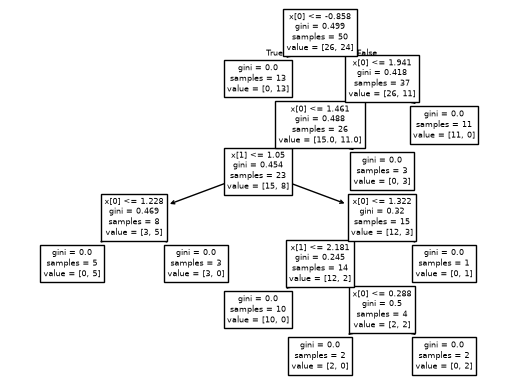

In [24]:
plot_tree(clf2)

[Text(0.5555555555555556, 0.9166666666666666, 'x[1] <= 0.27\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3333333333333333, 0.75, 'x[0] <= 1.06\ngini = 0.285\nsamples = 29\nvalue = [5, 24]'),
 Text(0.4444444444444444, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[0] <= 1.876\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.3333333333333333, 0.4166666666666667, 'x[1] <= -0.75\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2222222222222222, 0.25, 'x[0] <= 1.443\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1111111111111111, 0.08333333333333333, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5555555555555556, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]

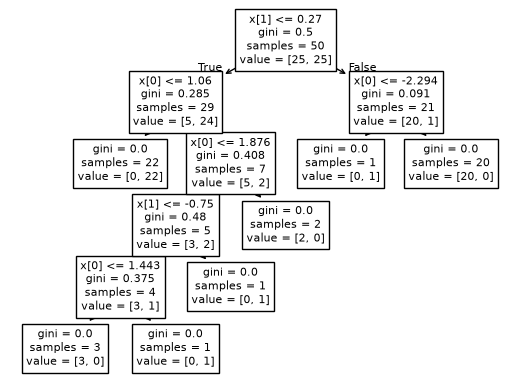

In [25]:
plot_tree(clf3)

In [26]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\sujat\projects\100-days-of-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [27]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\sujat\projects\100-days-of-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [28]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\sujat\projects\100-days-of-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [29]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
27,-1.190771,0.438349,-1.198488,3.075378,0.225445,1
2,-0.940463,0.102418,-0.347854,0.940216,0.004444,1
73,0.717185,3.119592,-3.672602,-0.910881,-3.789067,0
1,-0.432813,-1.258131,-0.403820,-0.080686,2.178338,1
28,2.805385,-0.770881,1.662267,0.952676,-0.800882,0
61,0.450343,1.787693,-0.096962,-0.811302,-1.497308,0
38,-0.507639,-2.725912,-1.557880,0.934093,2.980339,1
71,-2.463424,0.319316,-1.362831,-1.317288,-1.196666,1
75,1.982631,1.437287,-1.665571,0.584568,-1.579065,0
67,-1.711456,-0.439501,-1.274284,0.168642,-0.691239,1
